#Digital Speech Processing Lab

In [1]:
pip install numpy scipy matplotlib librosa soundfile scikit-learn


In [2]:
from google.colab import files
uploaded = files.upload()


Saving speech.wav to speech.wav


#Q1. Audio Loading and Signal Analysis

/tmp/ipython-input-3511543488.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


Sampling Rate (Hz): 44100
Number of Samples: 1764000
Duration (sec): 40.0
Max Amplitude: 27616
Min Amplitude: -27620


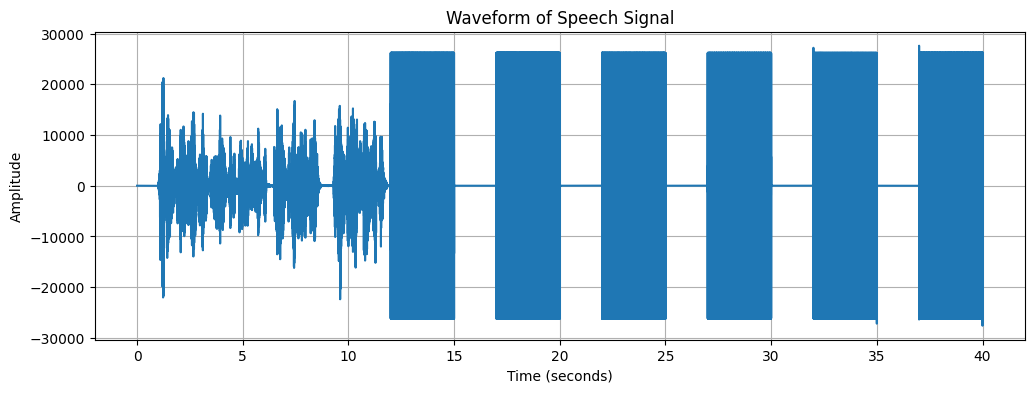

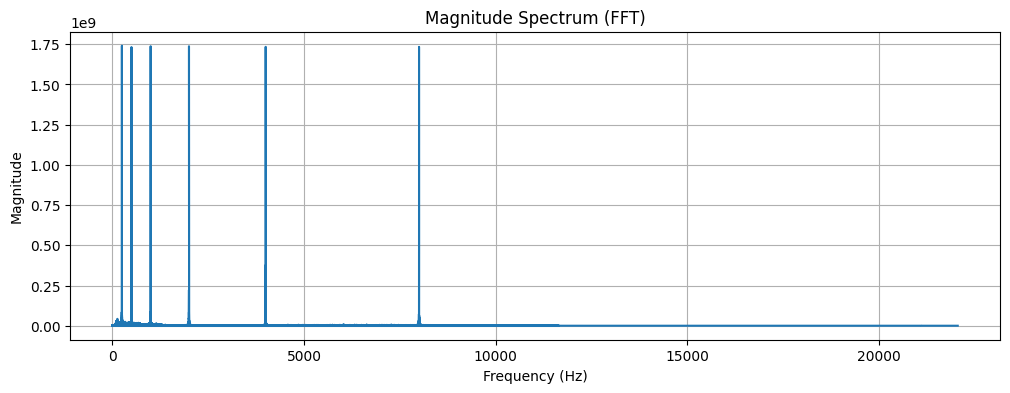

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1) Load the wav file
fs, x = wavfile.read("speech.wav")

# 2) If the audio is stereo, convert it to mono
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Number of samples
N = len(x)

# 4) Duration in seconds
duration = N / fs

# 5) Find max and min amplitude
max_amp = np.max(x)
min_amp = np.min(x)

# 6) Print basic info
print("Sampling Rate (Hz):", fs)
print("Number of Samples:", N)
print("Duration (sec):", duration)
print("Max Amplitude:", max_amp)
print("Min Amplitude:", min_amp)

# 7) Time axis for waveform plot
t = np.arange(N) / fs

# 8) Plot waveform
plt.figure(figsize=(12, 4))
plt.plot(t, x)
plt.title("Waveform of Speech Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 9) Compute FFT
X = np.fft.fft(x)

# 10) Frequency axis for FFT
freqs = np.fft.fftfreq(N, d=1/fs)

# 11) Take only positive frequencies
half = N // 2
freqs = freqs[:half]
magnitude = np.abs(X[:half])

# 12) Plot magnitude spectrum
plt.figure(figsize=(12, 4))
plt.plot(freqs, magnitude)
plt.title("Magnitude Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()


#Q2. Framing and Windowing (From Scratch)

/tmp/ipython-input-3961275127.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


Sampling Rate: 44100
Frame length (samples): 1102
Frame step (samples): 441
Total number of frames: 3999


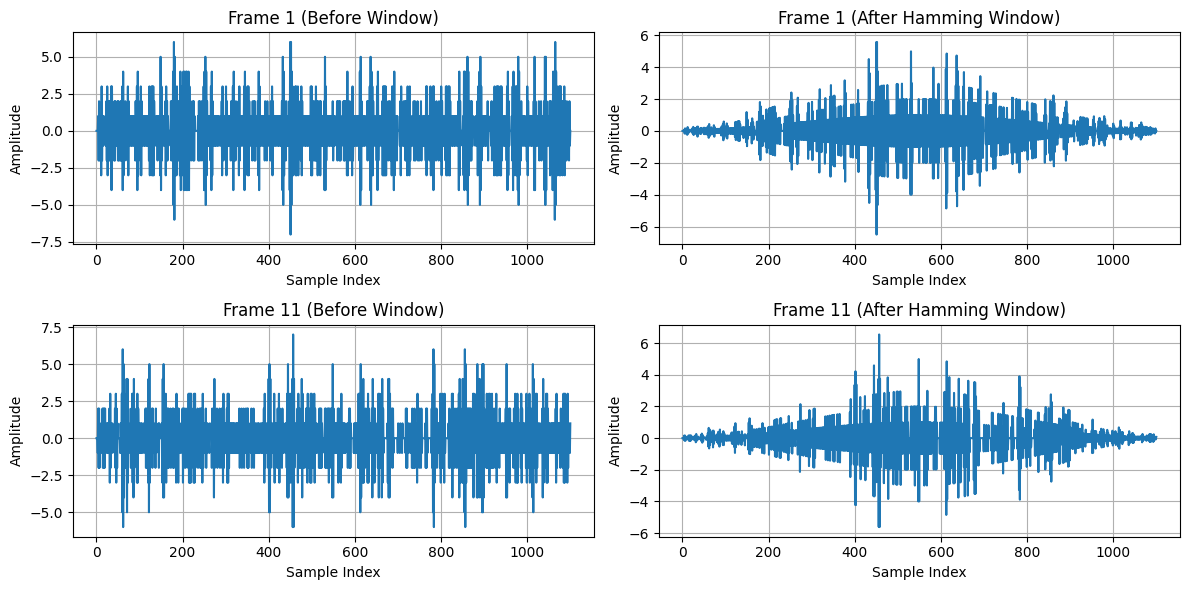

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1) Load the wav file
fs, x = wavfile.read("speech.wav")

# 2) Convert stereo to mono if needed
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Convert signal to float (recommended for DSP)
x = x.astype(np.float32)

# 4) Define frame size and frame shift in milliseconds
frame_size_ms = 25
frame_shift_ms = 10

# 5) Convert ms to number of samples
frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

# 6) Total number of samples
N = len(x)

# 7) Compute number of frames
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

# 8) Pad signal so that all frames have equal length
pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
x_padded = np.concatenate((x, np.zeros(pad_amount)))

# 9) Create a 2D array to store frames
frames = np.zeros((num_frames, frame_len))

# 10) Extract frames using a loop
for i in range(num_frames):
    start = i * frame_step
    end = start + frame_len
    frames[i] = x_padded[start:end]

# 11) Create Hamming window
hamming_window = np.hamming(frame_len)

# 12) Apply window to each frame
windowed_frames = frames * hamming_window

# 13) Print important info
print("Sampling Rate:", fs)
print("Frame length (samples):", frame_len)
print("Frame step (samples):", frame_step)
print("Total number of frames:", num_frames)

# 14) Pick two frames to show
frame1_index = 0
frame2_index = min(10, num_frames - 1)

# 15) Plot original and windowed frames
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(frames[frame1_index])
plt.title("Frame 1 (Before Window)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(windowed_frames[frame1_index])
plt.title("Frame 1 (After Hamming Window)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(frames[frame2_index])
plt.title(f"Frame {frame2_index+1} (Before Window)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(windowed_frames[frame2_index])
plt.title(f"Frame {frame2_index+1} (After Hamming Window)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.grid(True)

plt.tight_layout()
plt.show()


#Q3. STFT and Spectrogram Generation

/tmp/ipython-input-3878742016.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


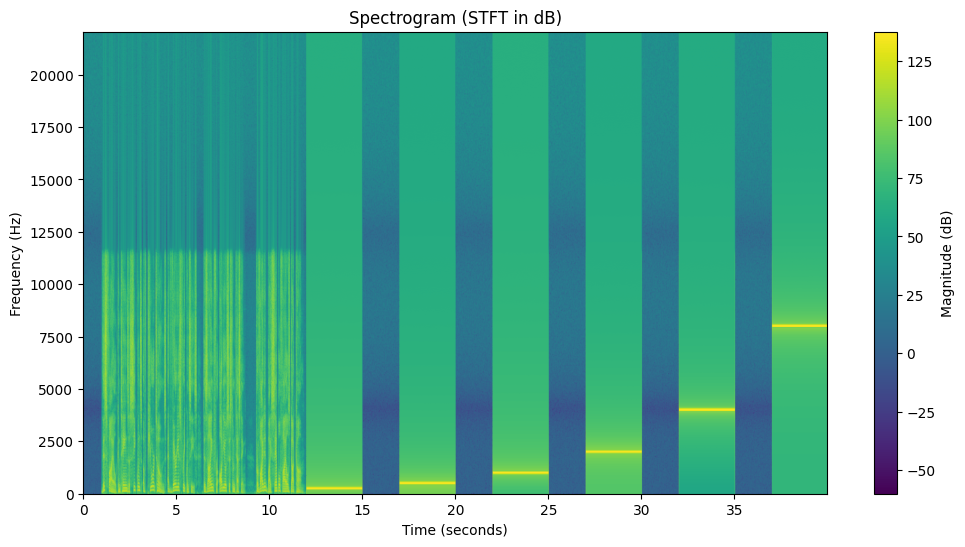

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1) Load the wav file
fs, x = wavfile.read("speech.wav")

# 2) Convert stereo to mono if needed
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Convert to float for DSP
x = x.astype(np.float32)

# 4) Define frame size and shift (in ms)
frame_size_ms = 25
frame_shift_ms = 10

# 5) Convert ms to samples
frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

# 6) Compute number of frames
N = len(x)
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

# 7) Pad signal
pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
x_padded = np.concatenate((x, np.zeros(pad_amount)))

# 8) Create Hamming window
window = np.hamming(frame_len)

# 9) Choose FFT size (usually power of 2 for speed)
nfft = 512
if frame_len > nfft:
    nfft = 1024

# 10) STFT matrix to store magnitude spectrum of each frame
stft_mag = np.zeros((num_frames, nfft // 2 + 1))

# 11) Perform STFT frame by frame
for i in range(num_frames):
    start = i * frame_step
    end = start + frame_len

    frame = x_padded[start:end]
    frame_windowed = frame * window

    # rfft gives only positive frequencies (0 to fs/2)
    spectrum = np.fft.rfft(frame_windowed, n=nfft)

    # magnitude spectrum
    stft_mag[i] = np.abs(spectrum)

# 12) Convert magnitude to dB (log scale)
eps = 1e-10
stft_db = 20 * np.log10(stft_mag + eps)

# 13) Time axis (frame centers)
times = np.arange(num_frames) * frame_step / fs

# 14) Frequency axis
freqs = np.linspace(0, fs / 2, nfft // 2 + 1)

# 15) Plot spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(
    stft_db.T,
    origin="lower",
    aspect="auto",
    extent=[times[0], times[-1], freqs[0], freqs[-1]]
)
plt.colorbar(label="Magnitude (dB)")
plt.title("Spectrogram (STFT in dB)")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()


#Q4. MFCC Extraction

/tmp/ipython-input-373839004.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


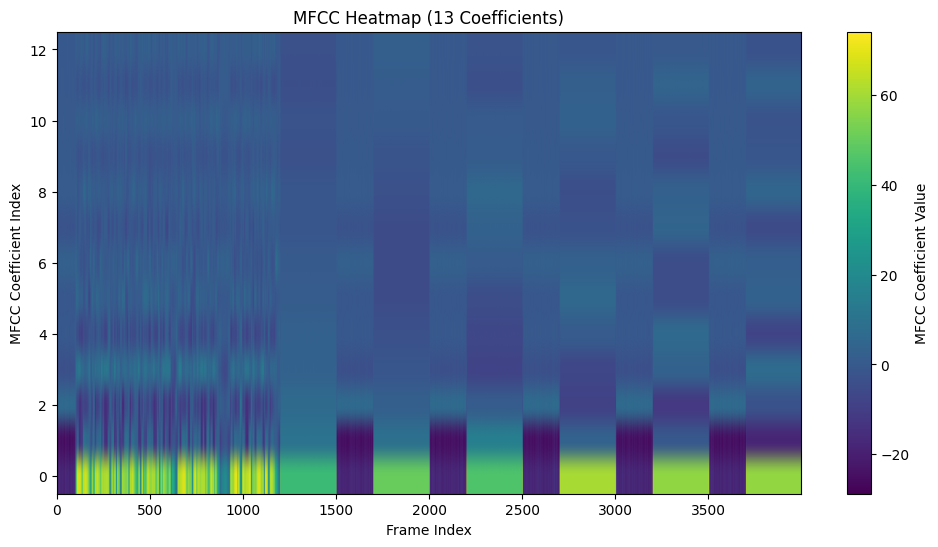

MFCC shape: (3999, 13)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct

# 1) Load the wav file
fs, x = wavfile.read("speech.wav")

# 2) Convert stereo to mono if needed
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Convert to float
x = x.astype(np.float32)

# -------------------------------
# Step 1: Pre-emphasis
# -------------------------------
pre_emphasis = 0.97
x_pre = np.append(x[0], x[1:] - pre_emphasis * x[:-1])

# -------------------------------
# Step 2: Framing
# -------------------------------
frame_size_ms = 25
frame_shift_ms = 10

frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

N = len(x_pre)
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
x_padded = np.concatenate((x_pre, np.zeros(pad_amount)))

frames = np.zeros((num_frames, frame_len))

for i in range(num_frames):
    start = i * frame_step
    end = start + frame_len
    frames[i] = x_padded[start:end]

# -------------------------------
# Step 3: Windowing (Hamming)
# -------------------------------
window = np.hamming(frame_len)
frames_win = frames * window

# -------------------------------
# Step 4: FFT and Power Spectrum
# -------------------------------
nfft = 512
if frame_len > nfft:
    nfft = 1024

fft_frames = np.fft.rfft(frames_win, n=nfft)
mag_frames = np.abs(fft_frames)

# Power spectrum (energy)
pow_frames = (1.0 / nfft) * (mag_frames ** 2)

# -------------------------------
# Step 5: Mel Filterbank
# -------------------------------
num_filters = 26
low_freq = 0
high_freq = fs / 2

def hz_to_mel(hz):
    return 2595 * np.log10(1 + hz / 700)

def mel_to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

# Convert Hz to Mel
low_mel = hz_to_mel(low_freq)
high_mel = hz_to_mel(high_freq)

# Equally spaced points in Mel scale
mel_points = np.linspace(low_mel, high_mel, num_filters + 2)

# Convert Mel points back to Hz
hz_points = mel_to_hz(mel_points)

# Convert Hz to FFT bin numbers
bin_points = np.floor((nfft + 1) * hz_points / fs).astype(int)

# Create filterbank matrix
fbank = np.zeros((num_filters, nfft // 2 + 1))

for m in range(1, num_filters + 1):
    f_m_minus = bin_points[m - 1]
    f_m = bin_points[m]
    f_m_plus = bin_points[m + 1]

    for k in range(f_m_minus, f_m):
        fbank[m - 1, k] = (k - f_m_minus) / (f_m - f_m_minus)

    for k in range(f_m, f_m_plus):
        fbank[m - 1, k] = (f_m_plus - k) / (f_m_plus - f_m)

# Apply filterbank
mel_energy = np.dot(pow_frames, fbank.T)

# -------------------------------
# Step 6: Log Mel Energies
# -------------------------------
eps = 1e-10
log_mel_energy = np.log(mel_energy + eps)

# -------------------------------
# Step 7: DCT to get MFCCs
# -------------------------------
num_mfcc = 13
mfcc = dct(log_mel_energy, type=2, axis=1, norm='ortho')[:, :num_mfcc]

# -------------------------------
# Plot MFCC Heatmap
# -------------------------------
plt.figure(figsize=(12, 6))
plt.imshow(mfcc.T, origin="lower", aspect="auto")
plt.colorbar(label="MFCC Coefficient Value")
plt.title("MFCC Heatmap (13 Coefficients)")
plt.xlabel("Frame Index")
plt.ylabel("MFCC Coefficient Index")
plt.show()

print("MFCC shape:", mfcc.shape)


#Q5. Pitch Detection Using Autocorrelation

/tmp/ipython-input-3806080575.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


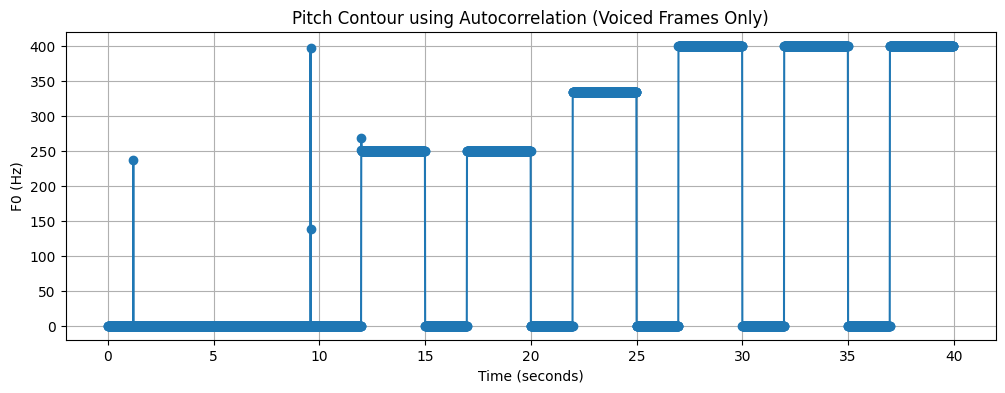

Total frames: 3999
Voiced frames: 1814


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1) Load the wav file
fs, x = wavfile.read("speech.wav")

# 2) Convert stereo to mono if needed
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Convert to float
x = x.astype(np.float32)

# -------------------------------
# Step 1: Framing
# -------------------------------
frame_size_ms = 25
frame_shift_ms = 10

frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

N = len(x)
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
x_padded = np.concatenate((x, np.zeros(pad_amount)))

frames = np.zeros((num_frames, frame_len))

for i in range(num_frames):
    start = i * frame_step
    end = start + frame_len
    frames[i] = x_padded[start:end]

# -------------------------------
# Step 2: Short-time energy for V/UV detection
# -------------------------------
energy = np.sum(frames ** 2, axis=1)

# Energy threshold (tuneable)
energy_threshold = 0.1 * np.max(energy)

# -------------------------------
# Step 3: Pitch detection using autocorrelation
# -------------------------------
# Typical pitch range for human speech:
# Male: 85–180 Hz
# Female: 165–255 Hz
# We'll use a general range:
f0_min = 50
f0_max = 400

# Convert frequency range to lag range
lag_min = int(fs / f0_max)
lag_max = int(fs / f0_min)

f0_values = np.zeros(num_frames)

for i in range(num_frames):

    # If energy is too low => unvoiced
    if energy[i] < energy_threshold:
        f0_values[i] = 0
        continue

    frame = frames[i]

    # Remove DC offset (important for autocorrelation)
    frame = frame - np.mean(frame)

    # Autocorrelation
    r = np.correlate(frame, frame, mode='full')

    # Keep only second half (positive lags)
    r = r[len(r)//2:]

    # Search for peak in valid lag range
    r_segment = r[lag_min:lag_max]

    peak_index = np.argmax(r_segment)
    best_lag = peak_index + lag_min

    # Convert lag to frequency
    f0 = fs / best_lag
    f0_values[i] = f0

# -------------------------------
# Step 4: Time axis for pitch contour
# -------------------------------
times = np.arange(num_frames) * frame_step / fs

# -------------------------------
# Step 5: Plot pitch contour
# -------------------------------
plt.figure(figsize=(12, 4))
plt.plot(times, f0_values, marker='o', linestyle='-')
plt.title("Pitch Contour using Autocorrelation (Voiced Frames Only)")
plt.xlabel("Time (seconds)")
plt.ylabel("F0 (Hz)")
plt.grid(True)
plt.show()

print("Total frames:", num_frames)
print("Voiced frames:", np.sum(f0_values > 0))


#Q6. Speech Enhancement by Spectral Subtraction

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 1) Load clean speech
fs, clean = wavfile.read("speech.wav")

# 2) Convert to mono if needed
if len(clean.shape) == 2:
    clean = clean[:, 0]

# 3) Convert to float
clean = clean.astype(np.float32)

# -------------------------------------------------
# Step A: Add white noise at given SNR
# -------------------------------------------------
snr_db = 10  # desired SNR in dB

# Generate white noise
noise = np.random.randn(len(clean))

# Compute signal and noise power
signal_power = np.mean(clean ** 2)
noise_power = np.mean(noise ** 2)

# Scale noise to required SNR
desired_noise_power = signal_power / (10 ** (snr_db / 10))
noise = noise * np.sqrt(desired_noise_power / noise_power)

# Noisy speech
noisy = clean + noise

# -------------------------------------------------
# Step B: Spectral Subtraction
# -------------------------------------------------
frame_size_ms = 25
frame_shift_ms = 10

frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

N = len(noisy)
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
noisy_padded = np.concatenate((noisy, np.zeros(pad_amount)))

# Hamming window
window = np.hamming(frame_len)

nfft = 512
enhanced = np.zeros_like(noisy_padded)

# Estimate noise spectrum from first few frames (assumed silence)
num_noise_frames = 5
noise_spec = np.zeros(nfft // 2 + 1)

for i in range(num_noise_frames):
    frame = noisy_padded[i*frame_step : i*frame_step + frame_len]
    frame = frame * window
    spectrum = np.fft.rfft(frame, nfft)
    noise_spec += np.abs(spectrum)

noise_spec /= num_noise_frames

# Process each frame
for i in range(num_frames):
    start = i * frame_step
    frame = noisy_padded[start:start + frame_len]
    frame_win = frame * window

    spectrum = np.fft.rfft(frame_win, nfft)
    mag = np.abs(spectrum)
    phase = np.angle(spectrum)

    # Spectral subtraction
    mag_clean = mag - noise_spec
    mag_clean = np.maximum(mag_clean, 0)

    # Reconstruct spectrum
    spectrum_clean = mag_clean * np.exp(1j * phase)

    # IFFT
    frame_clean = np.fft.irfft(spectrum_clean, nfft)
    enhanced[start:start + frame_len] += frame_clean[:frame_len]

# Trim to original length
enhanced = enhanced[:len(clean)]

# -------------------------------------------------
# Step C: Compute SNR before and after
# -------------------------------------------------
def compute_snr(clean, processed):
    noise = clean - processed
    return 10 * np.log10(np.sum(clean ** 2) / np.sum(noise ** 2))

snr_before = compute_snr(clean, noisy)
snr_after = compute_snr(clean, enhanced)

print("SNR before enhancement (dB):", snr_before)
print("SNR after enhancement (dB):", snr_after)
print("SNR improvement (dB):", snr_after - snr_before)

# -------------------------------------------------
# Plot signals
# -------------------------------------------------
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(clean)
plt.title("Clean Speech")
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(noisy)
plt.title("Noisy Speech (10 dB SNR)")
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(enhanced)
plt.title("Enhanced Speech (Spectral Subtraction)")
plt.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipython-input-2720542355.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, clean = wavfile.read("speech.wav")


ValueError: operands could not be broadcast together with shapes (1102,) (512,) (1102,) 

/tmp/ipython-input-2134773859.py:9: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, clean = wav.read("speech.wav")


SNR Before Enhancement (dB): 10.0
SNR After Enhancement (dB): 8.62
SNR Improvement (dB): -1.38


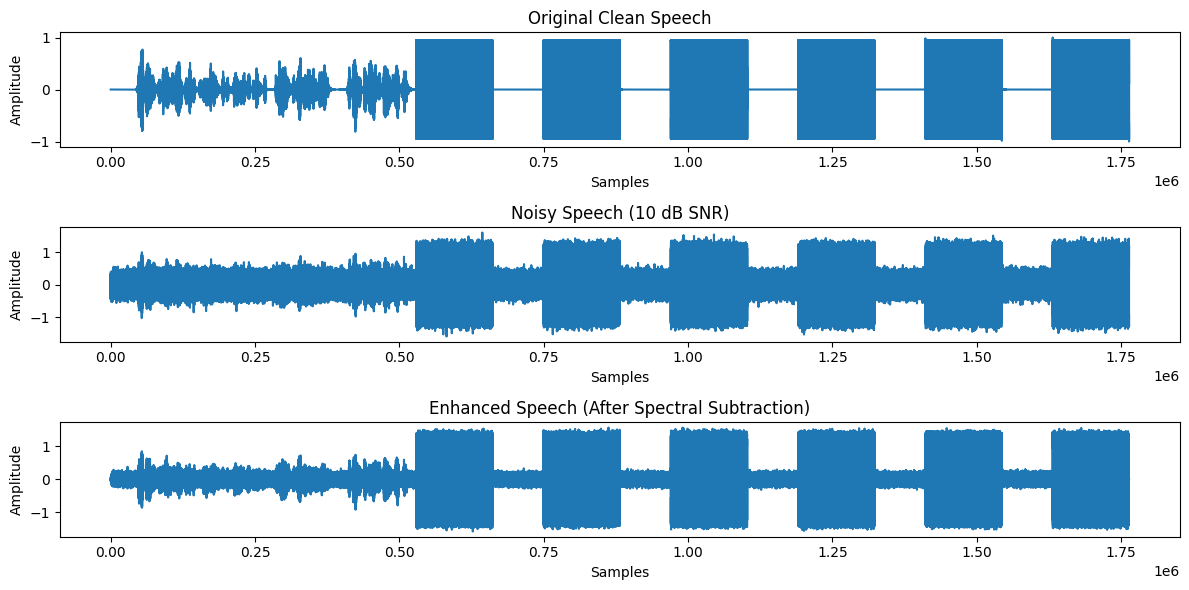

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.fft import rfft, irfft

# ===============================
# 1️⃣ Load Clean Speech Signal
# ===============================
fs, clean = wav.read("speech.wav")

# Convert stereo to mono
if len(clean.shape) == 2:
    clean = clean.mean(axis=1)

# Convert to float and normalize
clean = clean.astype(np.float32)
clean = clean / (np.max(np.abs(clean)) + 1e-8)

# ===============================
# 2️⃣ (a) Add White Noise at SNR = 10 dB
# ===============================
SNR_db = 10

# Generate white noise
noise = np.random.randn(len(clean))

# Calculate signal and noise power
signal_power = np.mean(clean**2)
noise_power = np.mean(noise**2)

# Scale noise to get desired SNR
desired_noise_power = signal_power / (10**(SNR_db / 10))
noise = noise * np.sqrt(desired_noise_power / noise_power)

# Noisy signal
noisy = clean + noise

# ===============================
# 3️⃣ Framing Parameters (for Spectral Subtraction)
# ===============================
frame_size = int(0.025 * fs)   # 25 ms
frame_shift = int(0.01 * fs)   # 10 ms

# Framing
frames = []
for i in range(0, len(noisy) - frame_size, frame_shift):
    frames.append(noisy[i:i + frame_size])

frames = np.array(frames)

# Hamming window
window = np.hamming(frame_size)
windowed_frames = frames * window

# ===============================
# 4️⃣ (b) Spectral Subtraction
# ===============================
NFFT = frame_size
enhanced_frames = []

# Estimate noise spectrum from first few frames (assume noise-dominant)
noise_frames = windowed_frames[:5]
noise_spectrum = np.mean(np.abs(rfft(noise_frames, NFFT)), axis=0)

for frame in windowed_frames:
    spectrum = rfft(frame, NFFT)
    magnitude = np.abs(spectrum)
    phase = np.angle(spectrum)

    # Spectral subtraction
    clean_mag = magnitude - noise_spectrum
    clean_mag = np.maximum(clean_mag, 0)  # avoid negative values

    # Reconstruct spectrum
    enhanced_spectrum = clean_mag * np.exp(1j * phase)

    # Inverse FFT
    enhanced_frame = irfft(enhanced_spectrum, NFFT)
    enhanced_frames.append(enhanced_frame)

enhanced_frames = np.array(enhanced_frames)

# Overlap-add reconstruction
enhanced = np.zeros(len(noisy))
index = 0
for frame in enhanced_frames:
    enhanced[index:index + frame_size] += frame
    index += frame_shift

# ===============================
# 5️⃣ (c) Compute SNR Before and After Enhancement
# ===============================
# Match length
min_len = min(len(clean), len(enhanced))
clean = clean[:min_len]
noisy = noisy[:min_len]
enhanced = enhanced[:min_len]

# SNR Before Enhancement
noise_before = noisy - clean
snr_before = 10 * np.log10(np.sum(clean**2) / (np.sum(noise_before**2) + 1e-8))

# SNR After Enhancement
noise_after = enhanced - clean
snr_after = 10 * np.log10(np.sum(clean**2) / (np.sum(noise_after**2) + 1e-8))

print("SNR Before Enhancement (dB):", round(snr_before, 2))
print("SNR After Enhancement (dB):", round(snr_after, 2))
print("SNR Improvement (dB):", round(snr_after - snr_before, 2))

# ===============================
# Plot Waveforms (Optional but Good for Lab)
# ===============================
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(clean)
plt.title("Original Clean Speech")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 2)
plt.plot(noisy)
plt.title("Noisy Speech (10 dB SNR)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.subplot(3, 1, 3)
plt.plot(enhanced)
plt.title("Enhanced Speech (After Spectral Subtraction)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

#Q7. DTW-Based Isolated Word Recognition

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct

# ------------------------------------------
# MFCC FUNCTION (same pipeline as Q4)
# ------------------------------------------
def mfcc_extract(signal, fs, num_mfcc=13, num_filters=26, nfft=512):

    signal = signal.astype(np.float32)

    # Pre-emphasis
    pre_emphasis = 0.97
    signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

    # Framing
    frame_len = int(fs * 25 / 1000)
    frame_step = int(fs * 10 / 1000)

    N = len(signal)
    num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

    pad_len = (num_frames - 1) * frame_step + frame_len
    pad_amount = pad_len - N
    signal = np.concatenate((signal, np.zeros(pad_amount)))

    frames = np.zeros((num_frames, frame_len))
    for i in range(num_frames):
        start = i * frame_step
        frames[i] = signal[start:start + frame_len]

    # Windowing
    window = np.hamming(frame_len)
    frames = frames * window

    # FFT and power spectrum
    fft_frames = np.fft.rfft(frames, n=nfft)
    mag = np.abs(fft_frames)
    pow_spec = (1.0 / nfft) * (mag ** 2)

    # Mel filterbank
    def hz_to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    def mel_to_hz(mel):
        return 700 * (10**(mel / 2595) - 1)

    low_mel = hz_to_mel(0)
    high_mel = hz_to_mel(fs / 2)

    mel_points = np.linspace(low_mel, high_mel, num_filters + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((nfft + 1) * hz_points / fs).astype(int)

    fbank = np.zeros((num_filters, nfft // 2 + 1))

    for m in range(1, num_filters + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        for k in range(left, center):
            fbank[m - 1, k] = (k - left) / (center - left)

        for k in range(center, right):
            fbank[m - 1, k] = (right - k) / (right - center)

    mel_energy = np.dot(pow_spec, fbank.T)

    # log
    eps = 1e-10
    log_mel = np.log(mel_energy + eps)

    # DCT -> MFCC
    mfcc = dct(log_mel, type=2, axis=1, norm='ortho')[:, :num_mfcc]

    return mfcc


# ------------------------------------------
# DTW DISTANCE FUNCTION (from scratch)
# ------------------------------------------
def dtw_distance(A, B):
    """
    A: MFCC sequence (frames x coeff)
    B: MFCC sequence (frames x coeff)
    """

    n = A.shape[0]
    m = B.shape[0]

    # Cost matrix
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0

    # Fill DP table
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(A[i - 1] - B[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    return D[n, m]


# ------------------------------------------
# LOAD TRAINING DATASET
# ------------------------------------------
train_path = "dataset/train"
test_path = "dataset/test"

words = sorted(os.listdir(train_path))

train_templates = {}

for word in words:
    word_folder = os.path.join(train_path, word)
    files = sorted(os.listdir(word_folder))

    mfcc_list = []
    for f in files:
        fs, x = wavfile.read(os.path.join(word_folder, f))
        if len(x.shape) == 2:
            x = x[:, 0]
        mfcc_feat = mfcc_extract(x, fs)
        mfcc_list.append(mfcc_feat)

    train_templates[word] = mfcc_list


# ------------------------------------------
# TESTING
# ------------------------------------------
true_labels = []
pred_labels = []

for word in words:
    word_folder = os.path.join(test_path, word)
    files = sorted(os.listdir(word_folder))

    for f in files:
        fs, x = wavfile.read(os.path.join(word_folder, f))
        if len(x.shape) == 2:
            x = x[:, 0]
        test_mfcc = mfcc_extract(x, fs)

        # Find best DTW match
        best_word = None
        best_dist = np.inf

        for train_word in words:
            for template in train_templates[train_word]:
                dist = dtw_distance(test_mfcc, template)
                if dist < best_dist:
                    best_dist = dist
                    best_word = train_word

        true_labels.append(word)
        pred_labels.append(best_word)

        print(f"Test file: {f} | True: {word} | Predicted: {best_word} | DTW: {best_dist:.2f}")


# ------------------------------------------
# ACCURACY
# ------------------------------------------
true_labels = np.array(true_labels)
pred_labels = np.array(pred_labels)

accuracy = np.mean(true_labels == pred_labels)
print("\nAccuracy:", accuracy * 100, "%")


# ------------------------------------------
# CONFUSION MATRIX (from scratch)
# ------------------------------------------
conf_mat = np.zeros((len(words), len(words)), dtype=int)

for t, p in zip(true_labels, pred_labels):
    i = words.index(t)
    j = words.index(p)
    conf_mat[i, j] += 1

plt.figure(figsize=(7, 6))
plt.imshow(conf_mat, origin="upper", aspect="auto")
plt.colorbar(label="Count")
plt.title("Confusion Matrix (DTW Word Recognition)")
plt.xlabel("Predicted Word")
plt.ylabel("True Word")
plt.xticks(range(len(words)), words)
plt.yticks(range(len(words)), words)

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, conf_mat[i, j], ha="center", va="center")

plt.show()


#Q8. Voice Activity Detection (VAD) and Segmentation

/tmp/ipython-input-952842431.py:7: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, x = wavfile.read("speech.wav")


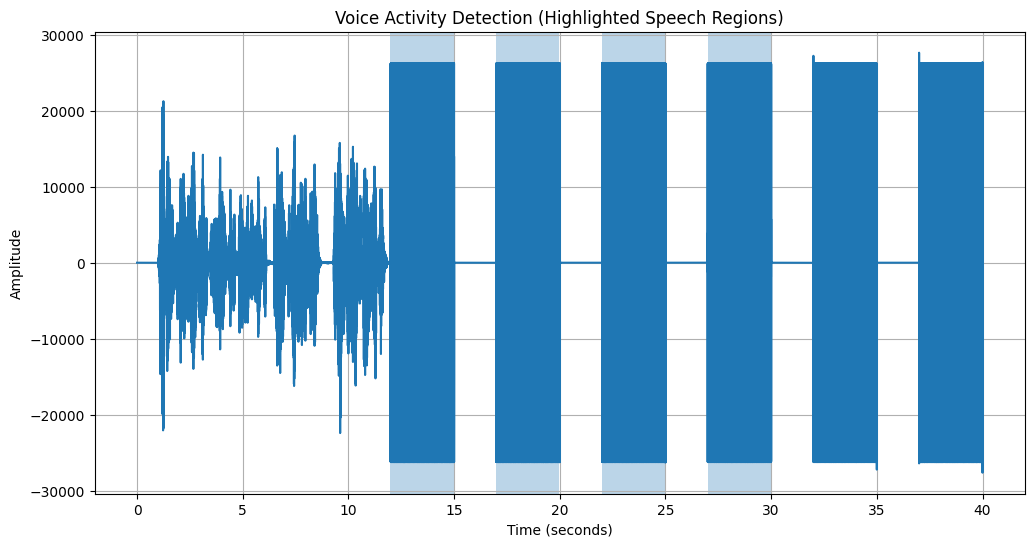

Total speech segments detected: 5
Saved segments in folder: vad_segments


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os

# 1) Load speech wav
fs, x = wavfile.read("speech.wav")

# 2) Convert stereo to mono if needed
if len(x.shape) == 2:
    x = x[:, 0]

# 3) Convert to float
x = x.astype(np.float32)

# -----------------------------------------
# Step 1: Framing
# -----------------------------------------
frame_size_ms = 25
frame_shift_ms = 10

frame_len = int(fs * frame_size_ms / 1000)
frame_step = int(fs * frame_shift_ms / 1000)

N = len(x)
num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

pad_len = (num_frames - 1) * frame_step + frame_len
pad_amount = pad_len - N
x_padded = np.concatenate((x, np.zeros(pad_amount)))

frames = np.zeros((num_frames, frame_len))

for i in range(num_frames):
    start = i * frame_step
    frames[i] = x_padded[start:start + frame_len]

# -----------------------------------------
# Step 2: Short-Time Energy
# -----------------------------------------
energy = np.sum(frames ** 2, axis=1)

# Normalize energy (0 to 1)
energy = energy / np.max(energy)

# -----------------------------------------
# Step 3: Zero Crossing Rate (ZCR)
# -----------------------------------------
zcr = np.zeros(num_frames)

for i in range(num_frames):
    frame = frames[i]
    signs = np.sign(frame)
    signs[signs == 0] = 1
    zcr[i] = np.sum(signs[:-1] != signs[1:]) / frame_len

# -----------------------------------------
# Step 4: VAD Decision Rule
# -----------------------------------------
energy_thresh = 0.1
zcr_thresh = 0.15

vad = (energy > energy_thresh) & (zcr < zcr_thresh)

# -----------------------------------------
# Step 5: Convert VAD frames into segments
# -----------------------------------------
segments = []
in_speech = False
start_frame = 0

for i in range(num_frames):
    if vad[i] and not in_speech:
        in_speech = True
        start_frame = i

    elif not vad[i] and in_speech:
        in_speech = False
        end_frame = i
        segments.append((start_frame, end_frame))

# If signal ends while still in speech
if in_speech:
    segments.append((start_frame, num_frames - 1))

# -----------------------------------------
# Step 6: Plot waveform + speech regions
# -----------------------------------------
t = np.arange(len(x)) / fs

plt.figure(figsize=(12, 6))
plt.plot(t, x, label="Waveform")

for (s, e) in segments:
    start_time = s * frame_step / fs
    end_time = e * frame_step / fs
    plt.axvspan(start_time, end_time, alpha=0.3)

plt.title("Voice Activity Detection (Highlighted Speech Regions)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# -----------------------------------------
# Step 7: Save speech segments as wav files
# -----------------------------------------
output_folder = "vad_segments"
os.makedirs(output_folder, exist_ok=True)

for idx, (s, e) in enumerate(segments):
    start_sample = s * frame_step
    end_sample = e * frame_step + frame_len
    segment_audio = x_padded[start_sample:end_sample]

    # Convert back to int16 for wav saving
    segment_audio_int16 = np.int16(segment_audio / np.max(np.abs(segment_audio)) * 32767)

    filename = os.path.join(output_folder, f"segment_{idx+1}.wav")
    wavfile.write(filename, fs, segment_audio_int16)

print("Total speech segments detected:", len(segments))
print("Saved segments in folder:", output_folder)


#Q9. Speaker Identification using Simple Embedding

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fftpack import dct

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ------------------------------------------
# MFCC Extraction Function (same as Q4)
# ------------------------------------------
def mfcc_extract(signal, fs, num_mfcc=13, num_filters=26, nfft=512):

    signal = signal.astype(np.float32)

    # Pre-emphasis
    pre_emphasis = 0.97
    signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

    # Framing
    frame_len = int(fs * 25 / 1000)
    frame_step = int(fs * 10 / 1000)

    N = len(signal)
    num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

    pad_len = (num_frames - 1) * frame_step + frame_len
    pad_amount = pad_len - N
    signal = np.concatenate((signal, np.zeros(pad_amount)))

    frames = np.zeros((num_frames, frame_len))
    for i in range(num_frames):
        start = i * frame_step
        frames[i] = signal[start:start + frame_len]

    # Windowing
    window = np.hamming(frame_len)
    frames = frames * window

    # FFT and power spectrum
    fft_frames = np.fft.rfft(frames, n=nfft)
    mag = np.abs(fft_frames)
    pow_spec = (1.0 / nfft) * (mag ** 2)

    # Mel filterbank
    def hz_to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    def mel_to_hz(mel):
        return 700 * (10**(mel / 2595) - 1)

    low_mel = hz_to_mel(0)
    high_mel = hz_to_mel(fs / 2)

    mel_points = np.linspace(low_mel, high_mel, num_filters + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((nfft + 1) * hz_points / fs).astype(int)

    fbank = np.zeros((num_filters, nfft // 2 + 1))

    for m in range(1, num_filters + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        for k in range(left, center):
            fbank[m - 1, k] = (k - left) / (center - left)

        for k in range(center, right):
            fbank[m - 1, k] = (right - k) / (right - center)

    mel_energy = np.dot(pow_spec, fbank.T)

    eps = 1e-10
    log_mel = np.log(mel_energy + eps)

    mfcc = dct(log_mel, type=2, axis=1, norm='ortho')[:, :num_mfcc]

    return mfcc


# ------------------------------------------
# Delta MFCC (difference between frames)
# ------------------------------------------
def delta_features(mfcc):
    delta = np.zeros_like(mfcc)
    delta[1:] = mfcc[1:] - mfcc[:-1]
    delta[0] = delta[1]
    return delta


# ------------------------------------------
# Build embedding: mean MFCC + mean delta
# ------------------------------------------
def speaker_embedding(signal, fs):
    mfcc = mfcc_extract(signal, fs)
    delta = delta_features(mfcc)

    mfcc_mean = np.mean(mfcc, axis=0)
    delta_mean = np.mean(delta, axis=0)

    embedding = np.concatenate([mfcc_mean, delta_mean])
    return embedding


# ------------------------------------------
# Load dataset
# ------------------------------------------
dataset_path = "speaker_dataset"

X = []
y = []

speakers = sorted(os.listdir(dataset_path))

for speaker in speakers:
    speaker_folder = os.path.join(dataset_path, speaker)
    files = sorted(os.listdir(speaker_folder))

    for f in files:
        fs, x = wavfile.read(os.path.join(speaker_folder, f))
        if len(x.shape) == 2:
            x = x[:, 0]

        emb = speaker_embedding(x, fs)
        X.append(emb)
        y.append(speaker)

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))
print("Embedding dimension:", X.shape[1])
print("Speakers:", speakers)


# ------------------------------------------
# Train/test split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# ------------------------------------------
# Train KNN classifier
# ------------------------------------------
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)


# ------------------------------------------
# Evaluate
# ------------------------------------------
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ------------------------------------------
# Confusion Matrix
# ------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=speakers)

plt.figure(figsize=(7, 6))
plt.imshow(cm, origin="upper", aspect="auto")
plt.colorbar(label="Count")
plt.title("Confusion Matrix (Speaker ID)")
plt.xlabel("Predicted Speaker")
plt.ylabel("True Speaker")
plt.xticks(range(len(speakers)), speakers, rotation=45)
plt.yticks(range(len(speakers)), speakers)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


#Q10. Real-Time Command Recognition

In [ ]:
pip install sounddevice scipy numpy matplotlib


In [ ]:
import numpy as np
import sounddevice as sd
from scipy.io import wavfile
from scipy.fftpack import dct

# ------------------------------------------
# Settings
# ------------------------------------------
fs = 16000
duration = 2  # seconds
commands = ["start", "stop"]
num_templates = 3

# ------------------------------------------
# MFCC extraction (simplified)
# ------------------------------------------
def mfcc_extract(signal, fs, num_mfcc=13, num_filters=26, nfft=512):

    signal = signal.astype(np.float32)

    # Pre-emphasis
    pre_emphasis = 0.97
    signal = np.append(signal[0], signal[1:] - pre_emphasis * signal[:-1])

    # Framing
    frame_len = int(fs * 25 / 1000)
    frame_step = int(fs * 10 / 1000)

    N = len(signal)
    num_frames = int(np.ceil((N - frame_len) / frame_step)) + 1

    pad_len = (num_frames - 1) * frame_step + frame_len
    pad_amount = pad_len - N
    signal = np.concatenate((signal, np.zeros(pad_amount)))

    frames = np.zeros((num_frames, frame_len))
    for i in range(num_frames):
        start = i * frame_step
        frames[i] = signal[start:start + frame_len]

    # Windowing
    frames *= np.hamming(frame_len)

    # FFT and power spectrum
    fft_frames = np.fft.rfft(frames, n=nfft)
    mag = np.abs(fft_frames)
    pow_spec = (1.0 / nfft) * (mag ** 2)

    # Mel filterbank
    def hz_to_mel(hz):
        return 2595 * np.log10(1 + hz / 700)

    def mel_to_hz(mel):
        return 700 * (10**(mel / 2595) - 1)

    low_mel = hz_to_mel(0)
    high_mel = hz_to_mel(fs / 2)

    mel_points = np.linspace(low_mel, high_mel, num_filters + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((nfft + 1) * hz_points / fs).astype(int)

    fbank = np.zeros((num_filters, nfft // 2 + 1))

    for m in range(1, num_filters + 1):
        left = bins[m - 1]
        center = bins[m]
        right = bins[m + 1]

        for k in range(left, center):
            fbank[m - 1, k] = (k - left) / (center - left)

        for k in range(center, right):
            fbank[m - 1, k] = (right - k) / (right - center)

    mel_energy = np.dot(pow_spec, fbank.T)

    eps = 1e-10
    log_mel = np.log(mel_energy + eps)

    mfcc = dct(log_mel, type=2, axis=1, norm='ortho')[:, :num_mfcc]

    return mfcc


# ------------------------------------------
# DTW function (same as Q7)
# ------------------------------------------
def dtw_distance(A, B):
    n = A.shape[0]
    m = B.shape[0]

    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(A[i - 1] - B[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])

    return D[n, m]


# ------------------------------------------
# Record function
# ------------------------------------------
def record_audio(duration, fs):
    print(f"Recording for {duration} seconds...")
    audio = sd.rec(int(duration * fs), samplerate=fs, channels=1, dtype=np.float32)
    sd.wait()
    return audio.flatten()


# ------------------------------------------
# Training templates
# ------------------------------------------
templates = {cmd: [] for cmd in commands}

print("\n=== TRAINING PHASE ===")
for cmd in commands:
    for i in range(num_templates):
        input(f"\nPress Enter and say '{cmd}' (template {i+1}/{num_templates})...")
        audio = record_audio(duration, fs)
        mfcc = mfcc_extract(audio, fs)
        templates[cmd].append(mfcc)

print("\nTraining complete!\n")


# ------------------------------------------
# Testing phase
# ------------------------------------------
print("=== TESTING PHASE ===")
input("\nPress Enter and say a command (start/stop)...")
test_audio = record_audio(duration, fs)
test_mfcc = mfcc_extract(test_audio, fs)

best_cmd = None
best_dist = np.inf

for cmd in commands:
    for temp in templates[cmd]:
        dist = dtw_distance(test_mfcc, temp)
        if dist < best_dist:
            best_dist = dist
            best_cmd = cmd

print("\nPredicted Command:", best_cmd)
print("DTW Distance:", best_dist)
